In [20]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


In [21]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )

def cooling_law(time, Tenv, T0, R):
    T = Tenv + (T0 - Tenv) * torch.exp(-R * time)
    return T

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

def np_to_th(x):
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)

class Net(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.SiLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.SiLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.SiLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.SiLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)
        
        # Move the entire model to the target device automatically.
        self.to(DEVICE)

    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)
        return out

    def fit(self, X, y):
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())

            # Custom callback for discovery
            if hasattr(self, 'r_history'):
                self.r_history.append(self.r.item())

            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.4f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()

class NetDiscovery(Net):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=0.001,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__(
            input_dim, output_dim, n_units, epochs, loss, lr, loss2, loss2_weight
        )
        self.r = nn.Parameter(data=torch.tensor([0.001], device=DEVICE))
        self.r_history = []

Text(0.5, 0, 'Time (s)')

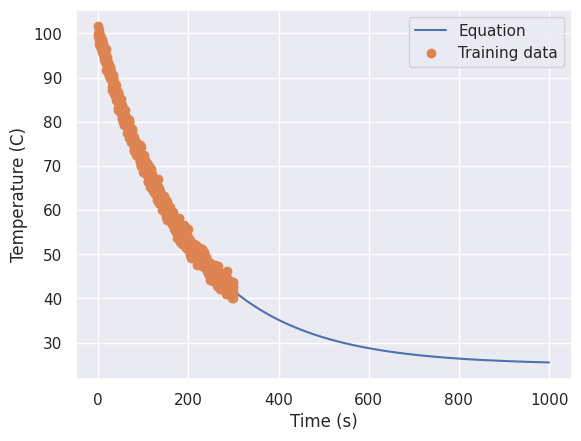

In [23]:
torch.manual_seed(10)

Tenv = 25
T0 = 100
R = 0.005
number_of_points = 1000
noise_coeff = 1

times = torch.linspace(0, 1000, number_of_points, device=DEVICE)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

t = torch.linspace(0, 300, number_of_points, device=DEVICE)
T = eq(t) + noise_coeff * torch.randn(number_of_points, device=DEVICE)

plt.plot(times.cpu().numpy(), temps.cpu().numpy())
plt.plot(t.cpu().numpy(), T.cpu().numpy(), 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# PINN

In [24]:
def physics_loss(model: torch.nn.Module, n_points=5000):
    ts = torch.linspace(0, 1000, steps=n_points, device=DEVICE).view(-1, 1).requires_grad_(True)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/30000, loss: 4328.8506
Epoch 3000/30000, loss: 2005.3972
Epoch 6000/30000, loss: 1620.2599
Epoch 9000/30000, loss: 93.4998
Epoch 12000/30000, loss: 11.5378
Epoch 15000/30000, loss: 6.8560
Epoch 18000/30000, loss: 3.8076
Epoch 21000/30000, loss: 1.8409
Epoch 24000/30000, loss: 1.0687
Epoch 27000/30000, loss: 0.9671


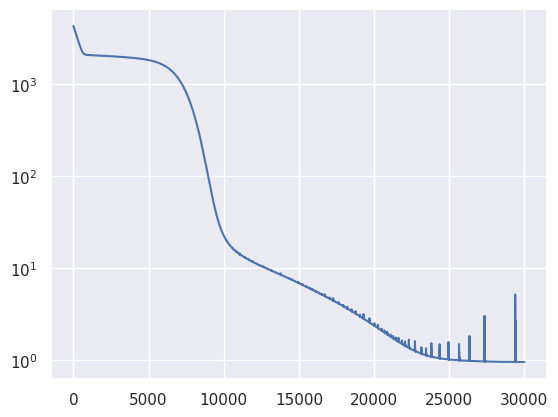

In [25]:
net = Net(1, 1, loss2=physics_loss, epochs=30000, loss2_weight=1, lr=1e-5).to(DEVICE)

losses = net.fit(t.cpu().numpy(), T.cpu().numpy())

plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Time (s)')

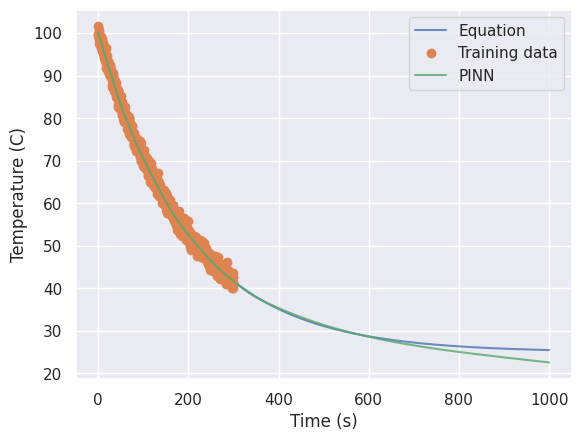

In [26]:
preds = net.predict(times.cpu().numpy())

plt.plot(times.cpu().numpy(), temps.cpu().numpy(), alpha=0.8)
plt.plot(t.cpu().numpy(), T.cpu().numpy(), 'o')
plt.plot(times.cpu().numpy(), preds, alpha=0.8)
plt.legend(labels=['Equation', 'Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# Parameter discovery

In [27]:
def physics_loss_discovery(model: torch.nn.Module, n_points=5000):
    ts = torch.linspace(0, 1000, steps=n_points, device=DEVICE).view(-1, 1).requires_grad_(True)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = torch.abs(model.r) * (Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/40000, loss: 4470.5850
Epoch 4000/40000, loss: 2051.5540
Epoch 8000/40000, loss: 1925.6248
Epoch 12000/40000, loss: 1396.0607
Epoch 16000/40000, loss: 310.8352
Epoch 20000/40000, loss: 14.0268
Epoch 24000/40000, loss: 8.7685
Epoch 28000/40000, loss: 5.2410
Epoch 32000/40000, loss: 2.8146
Epoch 36000/40000, loss: 1.4622


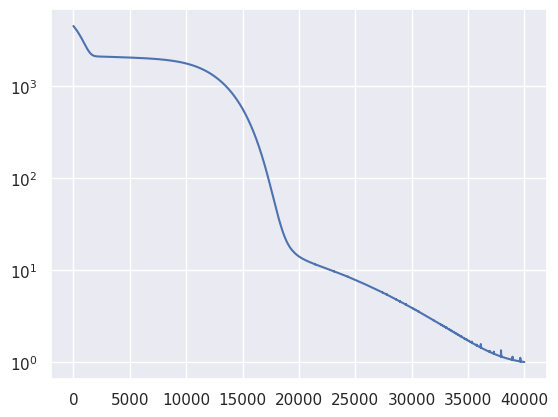

In [28]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=1, epochs=40000, lr=5e-6).to(DEVICE)

losses = netdisc.fit(t.cpu().numpy(), T.cpu().numpy())

plt.plot(losses)
plt.yscale('log')

Discovered R: 0.004150149878114462


Text(0.5, 0, 'Time (s)')

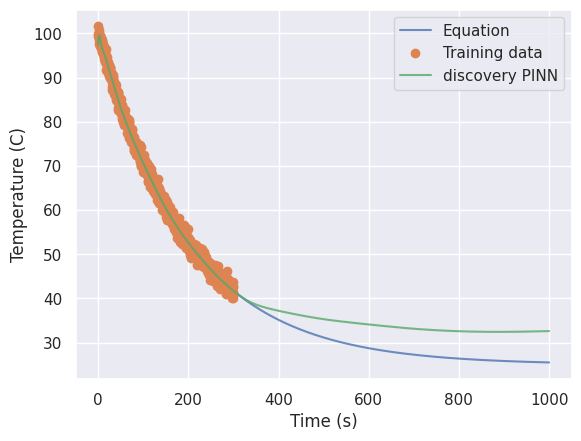

In [29]:
preds = netdisc.predict(times.cpu().numpy())
print(f"Discovered R: {netdisc.r.item()}")

plt.plot(times.cpu().numpy(), temps.cpu().numpy(), alpha=0.8)
plt.plot(t.cpu().numpy(), T.cpu().numpy(), 'o')
plt.plot(times.cpu().numpy(), preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')